In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install HD-BET

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [ ]:
# ***************************************************************************
# Skull Stripping + Registration: Use of these images were abandoned as sizing
# did not align with ground truth masks
# ***************************************************************************

orig_folders = []

for folder in os.listdir(training_base):
  orig_path = os.path.join(training_base, folder, "orig")
  if not os.path.isdir(orig_path):
    continue
  print(orig_path)
  orig_folders.append(orig_path)


/content/drive/MyDrive/ISBI 2015 Data/training/training03/orig
/content/drive/MyDrive/ISBI 2015 Data/training/training01/orig
/content/drive/MyDrive/ISBI 2015 Data/training/training02/orig
/content/drive/MyDrive/ISBI 2015 Data/training/training04/orig
/content/drive/MyDrive/ISBI 2015 Data/training/training05/orig


In [ ]:
# Skull Stripping using HD-BET to remove potential confounding
# non-brain tissue and allow for more accurate registration.

output_folder = "/content/drive/MyDrive/ISBI 2015 Data/skullstripped"

for folder in orig_folders:
  !hd-bet -i "{folder}" -o "{output_folder}" -device cpu --disable_tta


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 16 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 16 cases that I would like to predict

Predicting training05_01_flair_bet.nii.gz:
perform_everything_on_device: False
100% 12/12 [11:32<00:00, 57.70s/it]
sending off prediction to backgroun

35


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


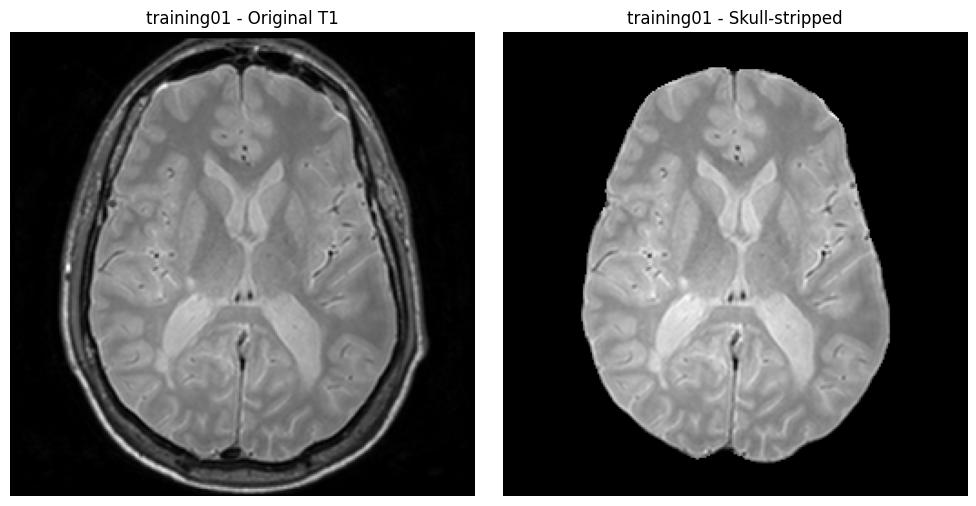

35


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


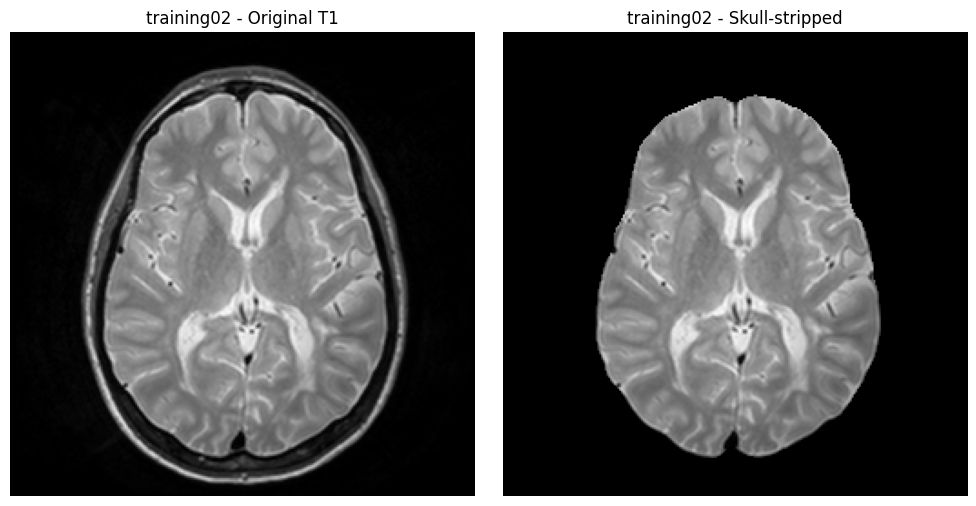

35


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


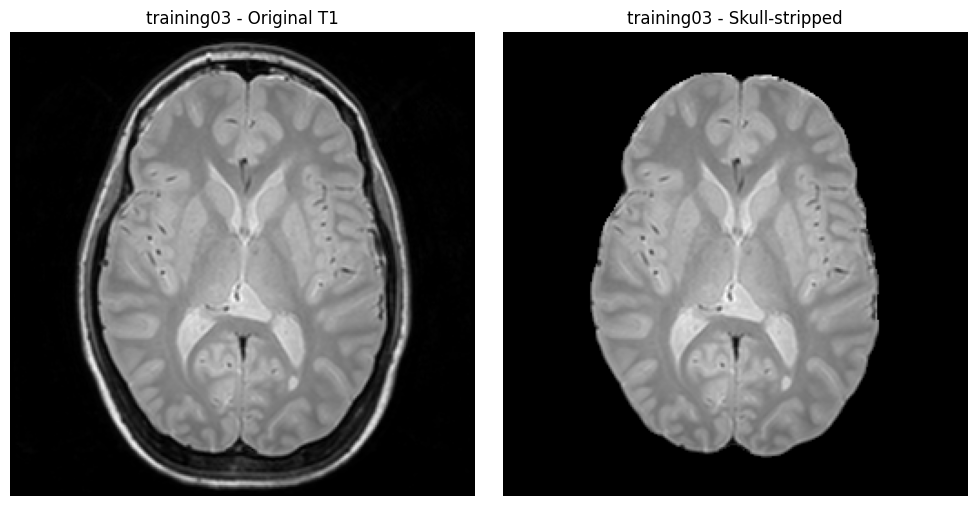

35


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


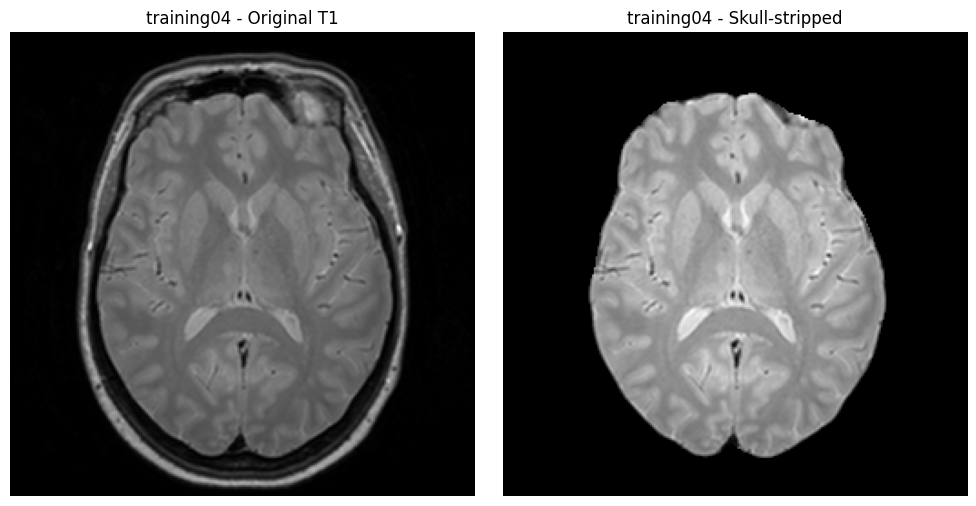

35


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


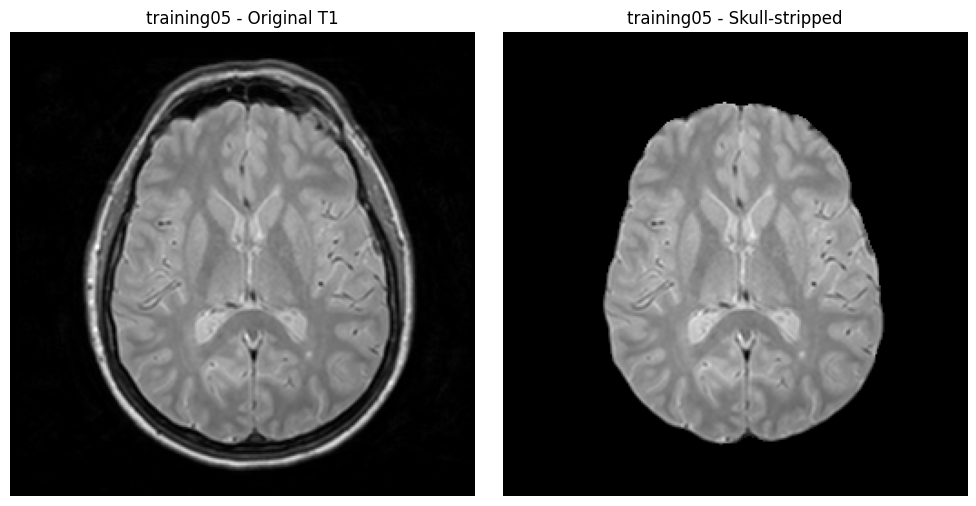

In [ ]:
# Preprocessing quality control: Visual Inspection of Skull stripped tissue
# to ensure brain tissue preservation.

import nibabel as nib
import matplotlib.pyplot as plt
import os

subjects = ['training01', 'training02', 'training03', 'training04', 'training05']
timepoint = '01'

for subj in subjects:
    orig_path = f'/content/drive/MyDrive/ISBI 2015 Data/training/{subj}/orig/{subj}_{timepoint}_pd.nii.gz'
    stripped_path = f'/content/drive/MyDrive/ISBI 2015 Data/skullstripped/{subj}_{timepoint}_pd.nii.gz'

    orig = nib.load(orig_path).get_fdata()
    stripped = nib.load(stripped_path).get_fdata()

    # selects mid-slice
    slice_idx = orig.shape[2] // 2

    # plots original compared to skull-stripped mri
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[0].set_title(f'{subj} - Original T1')
    axes[1].imshow(stripped[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[1].set_title(f'{subj} - Skull-stripped')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install antspyx


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 948.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
# Brain Registration based on T1 scans

import ants
inputDirectory = "/content/drive/MyDrive/ISBI 2015 Data/skullstripped"
outputDirectory = "/content/drive/MyDrive/ISBI 2015 Data/registration"

subjects = [f"training{sub:02d}" for sub in range(1, 5)]
timepoints = [f"{tp:02d}" for tp in range(1, 5)]
modality = ["flair", "pd", "t2"]

for subject in subjects:
  for timepoint in timepoints:
    T1Path = f"{inputDirectory}/{subject}_{timepoint}_mprage.nii.gz"
    fixedImage = ants.image_read(T1Path)
    for mod in modality:
      mod_path = f"{inputDirectory}/{subject}_{timepoint}_{mod}.nii.gz"
      movingImage = ants.image_read(mod_path)
      outputLabel = f"{outputDirectory}/{subject}_{timepoint}_{mod}_Warped.nii.gz"


      registration = ants.registration(fixedImage, movingImage, type_of_transform='Rigid')
      ants.image_write(registration['warpedmovout'], outputLabel)
      transform_log = f"{outputDirectory}/fwdtransforms_log.txt"

      with open(transform_log, "a") as f:
          f.write(f"{subject}_{timepoint}_{mod}: {registration['fwdtransforms']}\n")

In [ ]:
# ***************************************************************************
# 1. DATA PIPELINE: Normalization based on preprocessed images
# ***************************************************************************

import numpy as np

base_path = "/content/drive/MyDrive/ISBI 2015 Data/training"
out_path = "/content/drive/MyDrive/ISBI 2015 Data/normalized"

def intensity_normalization(img):
  brain_voxels = img[img > 0]
  mean = brain_voxels.mean()
  std = brain_voxels.std()

  normalized_img = (img - mean) / std
  return normalized_img


training_sets = ["training01", "training02", "training03", "training04", "training05"]
modalities = ["flair", "mprage", "pd", "t2"]
for train_set in training_sets:
  for val in range(1, 5):
    for mod in modalities:
      preprocess_path = f"{base_path}/{train_set}/preprocessed/{train_set}_{val:02d}_{mod}_pp.nii"
      orig_img = nib.load(preprocess_path)
      img = orig_img.get_fdata()

      normalized = intensity_normalization(img)
      normalized_nifti = nib.Nifti1Image(normalized, affine=orig_img.affine, header=orig_img.header)
      nib.save(normalized_nifti, f"{out_path}/{train_set}_{val:02d}_{mod}_norm.nii.gz")
      print(f"Saved {train_set} tp{val} {mod}")

Saved training01 tp1 flair
Saved training01 tp1 mprage
Saved training01 tp1 pd
Saved training01 tp1 t2
Saved training01 tp2 flair
Saved training01 tp2 mprage
Saved training01 tp2 pd
Saved training01 tp2 t2
Saved training01 tp3 flair
Saved training01 tp3 mprage
Saved training01 tp3 pd
Saved training01 tp3 t2
Saved training01 tp4 flair
Saved training01 tp4 mprage
Saved training01 tp4 pd
Saved training01 tp4 t2
Saved training02 tp1 flair
Saved training02 tp1 mprage
Saved training02 tp1 pd
Saved training02 tp1 t2
Saved training02 tp2 flair
Saved training02 tp2 mprage
Saved training02 tp2 pd
Saved training02 tp2 t2
Saved training02 tp3 flair
Saved training02 tp3 mprage
Saved training02 tp3 pd
Saved training02 tp3 t2
Saved training02 tp4 flair
Saved training02 tp4 mprage
Saved training02 tp4 pd
Saved training02 tp4 t2
Saved training03 tp1 flair
Saved training03 tp1 mprage
Saved training03 tp1 pd
Saved training03 tp1 t2
Saved training03 tp2 flair
Saved training03 tp2 mprage
Saved training03 t

In [5]:
# Here we create test/train/validation manifests at a 3/1/1 split to avoid data
# leakage from same patient's scans. Each manifest entry contains all 4
# modalities with corresponding lesion masks for one subject/timepoint.

import os

norm_path = "/content/drive/MyDrive/ISBI 2015 Data/normalized"
base_path = "/content/drive/MyDrive/ISBI 2015 Data/training"

train_subjects = ["training01", "training02", "training03"]
val_subjects = ["training04"]
test_subjects = ["training05"]

def build_manifest(subjects):
  manifest = []
  for subj in subjects:
    for val in range(1, 5):
      case = {
          "flair": f"{norm_path}/{subj}_{val:02d}_flair_norm.nii.gz",
          "t1": f"{norm_path}/{subj}_{val:02d}_mprage_norm.nii.gz",
          "t2": f"{norm_path}/{subj}_{val:02d}_t2_norm.nii.gz",
          "pd": f"{norm_path}/{subj}_{val:02d}_pd_norm.nii.gz",
          "mask": f"{base_path}/{subj}/masks/{subj}_{val:02d}_mask1.nii",
          }
      manifest.append(case)
  return manifest

train_manifest = build_manifest(train_subjects)
val_manifest = build_manifest(val_subjects)
test_manifest = build_manifest(test_subjects)

print(len(train_manifest), len(val_manifest), len(test_manifest))
print(train_manifest, val_manifest, test_manifest)


12 4 4
[{'flair': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_01_flair_norm.nii.gz', 't1': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_01_mprage_norm.nii.gz', 't2': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_01_t2_norm.nii.gz', 'pd': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_01_pd_norm.nii.gz', 'mask': '/content/drive/MyDrive/ISBI 2015 Data/training/training01/masks/training01_01_mask1.nii'}, {'flair': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_02_flair_norm.nii.gz', 't1': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_02_mprage_norm.nii.gz', 't2': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_02_t2_norm.nii.gz', 'pd': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_02_pd_norm.nii.gz', 'mask': '/content/drive/MyDrive/ISBI 2015 Data/training/training01/masks/training01_02_mask1.nii'}, {'flair': '/content/drive/MyDrive/ISBI 2015 Data/normalized/training01_03_

In [2]:
!pip install "monai[all]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/2

In [3]:
!python -m monai.bundle download "brats_mri_segmentation" --bundle_dir "/content/bundles"

2026-09-22 18:17:00.355890: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-22 18:17:00.483711: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-22 18:17:06,232 - INFO - --- input summary of monai.bundle.scripts.download ---
2026-09-22 18:17:06,232 - INFO - > name: 'brats_mri_segmentation'
2026-09-22 18:17:06,232 - INFO - > bundle_dir: '/content/bundles'
2026-09-22 18:17:06,232 - INFO - > source: 'monaihosting'
2026-09-22 18:17:06,232 - INFO - > remove_prefix: 'monai_'
2026-09-22 18:17:06,232 - INFO - > progress: True
2026-09-22 18:17:06,232 - INFO - ---


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0% 0/14 [00:0

In [ ]:
!cat /content/bundles/brats_mri_segmentation/configs/inference.json


{
    "imports": [
        "$import glob",
        "$import numpy",
        "$import os"
    ],
    "bundle_root": ".",
    "image_key": "image",
    "ckpt_dir": "$@bundle_root + '/models'",
    "output_dir": "$@bundle_root + '/eval'",
    "output_ext": ".nii.gz",
    "output_dtype": "uint8",
    "output_postfix": "seg",
    "separate_folder": true,
    "load_pretrain": true,
    "data_list_file_path": "$@bundle_root + '/configs/datalist.json'",
    "dataset_dir": "/workspace/data/medical/brats2018challenge",
    "test_datalist": "$monai.data.load_decathlon_datalist(@data_list_file_path, data_list_key='testing', base_dir=@dataset_dir)",
    "device": "$torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')",
    "amp": true,
    "network_def": {
        "_target_": "SegResNet",
        "blocks_down": [
            1,
            2,
            2,
            4
        ],
        "blocks_up": [
            1,
            1,
            1
        ],
        "init_filters": 16,
  

In [7]:
# ***************************************************************************
# 2. BASELINE EVALUATION
# ***************************************************************************

import torch
import numpy as np
import nibabel as nib
from monai.networks.nets import SegResNet
from monai.metrics import DiceMetric
from monai.transforms import SpatialPad

saved_examples = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegResNet(
  blocks_down=[1, 2, 2, 4],
  blocks_up=[1, 1, 1],
  init_filters=16,
  in_channels=4,
  out_channels=3,
  dropout_prob=0.2,).to(device)

# Load saved weights from brats model
checkpoint = torch.load("/content/bundles/brats_mri_segmentation/models/model.pt", map_location=device)
model.load_state_dict(checkpoint)
model.eval()

dice_metric = DiceMetric(include_background=True, reduction="mean")

# load images, temporarily add a channel dim for pad_transform, and
# pads to SegResNet's required input size (192 × 224 × 192)

pad_transform = SpatialPad(spatial_size=(192, 224, 192), mode="constant")

with torch.no_grad():
  for case in test_manifest:
    flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis, ...])[0]
    t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis, ...])[0]
    t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis, ...])[0]
    pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis, ...])[0]
    gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis, ...])[0])

    # brats take 4 channel inputs (t1, t1c, t2, flair), we replace t1c with pd
    stacked = np.stack([t1, pd, t2, flair], axis=0)

    input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)

    output = model(input_tensor)

    # Sigmoid Activation
    output = torch.sigmoid(output)

    # Here we use the whole tumour as a proxy for lesions based on the BraTS
    # channel definition ("0": "Tumor core", "1": "Whole tumor", "2": "Enhancing tumor")
    whole_tumor = output[:, 1:2]

    # Thresholding
    pred_mask = (whole_tumor > 0.5).float()

    gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

    if len(saved_examples) < 3:
      saved_examples.append((flair, gt_tensor, pred_mask))

    dice_metric(y_pred=pred_mask, y=gt_tensor)

mean_dice = dice_metric.aggregate().item()
dice_metric.reset()
print(f"Mean baseline Dice: {mean_dice:.4f}")

Stacked shape: (4, 192, 224, 192)
Stacked shape: (4, 192, 224, 192)
Stacked shape: (4, 192, 224, 192)
Stacked shape: (4, 192, 224, 192)
Mean baseline Dice: 0.0907


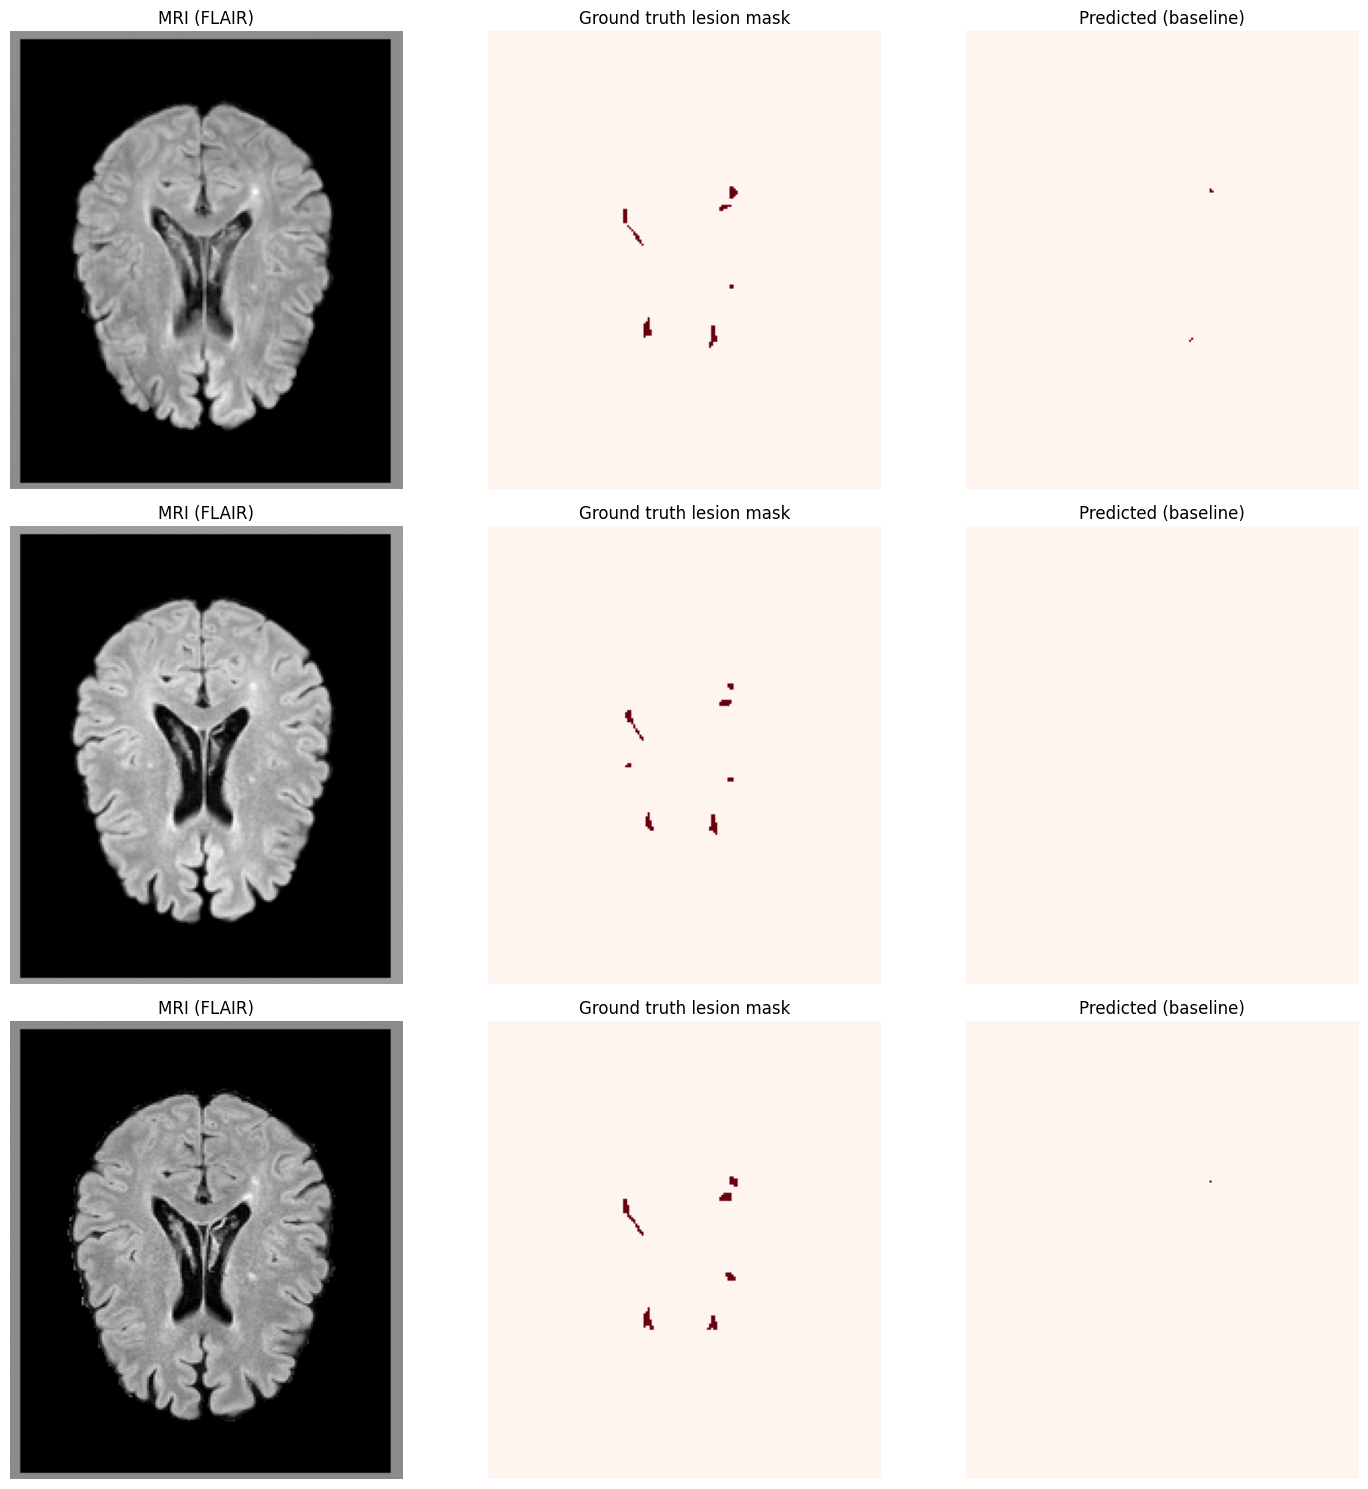

In [10]:
# Images of the original MRI, ground truth mask and predicted lesions using
# baseline BraTS model

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(saved_examples), 3, figsize=(15, 5 * len(saved_examples)))

for row, (flair, gt_tensor, pred_mask) in enumerate(saved_examples):
    slice_idx = pred_mask.shape[-1] // 2

    axes[row, 0].imshow(flair[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[row, 0].set_title('MRI (FLAIR)')

    axes[row, 1].imshow(gt_tensor[0, 0, :, :, slice_idx].cpu().T, cmap='Reds', origin='lower')
    axes[row, 1].set_title('Ground truth lesion mask')

    axes[row, 2].imshow(pred_mask[0, 0, :, :, slice_idx].cpu().T, cmap='Reds', origin='lower')
    axes[row, 2].set_title('Predicted (baseline)')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ISBI 2015 Data/baseline_images.png")
plt.show()

In [ ]:
for name, param in model.named_parameters():
    print(name)

convInit.conv.weight
down_layers.0.1.norm1.weight
down_layers.0.1.norm1.bias
down_layers.0.1.norm2.weight
down_layers.0.1.norm2.bias
down_layers.0.1.conv1.conv.weight
down_layers.0.1.conv2.conv.weight
down_layers.1.0.conv.weight
down_layers.1.1.norm1.weight
down_layers.1.1.norm1.bias
down_layers.1.1.norm2.weight
down_layers.1.1.norm2.bias
down_layers.1.1.conv1.conv.weight
down_layers.1.1.conv2.conv.weight
down_layers.1.2.norm1.weight
down_layers.1.2.norm1.bias
down_layers.1.2.norm2.weight
down_layers.1.2.norm2.bias
down_layers.1.2.conv1.conv.weight
down_layers.1.2.conv2.conv.weight
down_layers.2.0.conv.weight
down_layers.2.1.norm1.weight
down_layers.2.1.norm1.bias
down_layers.2.1.norm2.weight
down_layers.2.1.norm2.bias
down_layers.2.1.conv1.conv.weight
down_layers.2.1.conv2.conv.weight
down_layers.2.2.norm1.weight
down_layers.2.2.norm1.bias
down_layers.2.2.norm2.weight
down_layers.2.2.norm2.bias
down_layers.2.2.conv1.conv.weight
down_layers.2.2.conv2.conv.weight
down_layers.3.0.conv.we

In [ ]:
# ***************************************************************************
# 3. FINE-TUNING - ATTEMPT 1
# ***************************************************************************

# Layers frozen: everything except conv_final (output layer)
# Epochs: 10
# Loss: Dice Loss

import torch
from monai.losses import DiceLoss
import numpy as np

# load pretrained BraTS checkpoint (starting point for fine-tuning)
model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2,
).to(device)

checkpoint = torch.load("/content/bundles/brats_mri_segmentation/models/model.pt", map_location=device)
model.load_state_dict(checkpoint)

# freeze everything except conv_final layers
for name, param in model.named_parameters():
  if not name.startswith("conv_final"):
    param.requires_grad = False
  else:
    param.requires_grad = True

def evaluate_on_val(model, val_manifest):
  model.eval()
  dice_metric.reset()
  with torch.no_grad():
    for case in val_manifest:
      flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis])[0]
      t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis])[0]
      t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis])[0]
      pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis])[0]
      gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis])[0])

      stacked = np.stack([t1, pd, t2, flair], axis=0)
      input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)
      gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

      output = model(input_tensor)
      whole_tumor = torch.sigmoid(output[:, 1:2])
      pred_mask = (whole_tumor > 0.5).float()

      dice_metric(y_pred=pred_mask, y=gt_tensor)

  model.train()
  return dice_metric.aggregate().item()

# set loss function and adam optimizer
loss_function = DiceLoss(sigmoid=True, include_background=True)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

# training loop
num_epochs = 10
model.train()

for epoch in range(num_epochs):
  epoch_loss = 0
  print(f"Running epoch{epoch + 1}")

  for case in train_manifest:
    flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis])[0]
    t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis])[0]
    t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis])[0]
    pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis])[0]
    gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis])[0])

    stacked = np.stack([t1, pd, t2, flair], axis=0)
    input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)
    gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

    optimizer.zero_grad()
    output = model(input_tensor)
    lesion = output[:, 1:2]

    loss = loss_function(lesion, gt_tensor)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  val_dice = evaluate_on_val(model, val_manifest)
  print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_manifest):.4f}, Dice Score: {val_dice:.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/ISBI 2015 Data/finetuned_model_convfinal.pt")
print("Saved fine-tuned model.")

Running epoch1
Epoch 1, Loss: 0.9429, Dice Score: 0.0011
Running epoch2
Epoch 2, Loss: 0.9364, Dice Score: 0.0011
Running epoch3
Epoch 3, Loss: 0.9370, Dice Score: 0.0015
Running epoch4
Epoch 4, Loss: 0.9366, Dice Score: 0.0015
Running epoch5
Epoch 5, Loss: 0.9489, Dice Score: 0.0015
Running epoch6
Epoch 6, Loss: 0.9306, Dice Score: 0.0015
Running epoch7
Epoch 7, Loss: 0.9433, Dice Score: 0.0017
Running epoch8
Epoch 8, Loss: 0.9446, Dice Score: 0.0020
Running epoch9
Epoch 9, Loss: 0.9354, Dice Score: 0.0020
Running epoch10
Epoch 10, Loss: 0.9312, Dice Score: 0.0022
Saved fine-tuned model.


In [ ]:

# ***************************************************************************
# 3. FINE-TUNING - ATTEMPT 2
# ***************************************************************************

# Layers frozen: freeze everything except decoder layers
# Epochs: 10
# Loss: Dice Loss

import torch
from monai.losses import DiceLoss
import numpy as np

# load pretrained BraTS checkpoint (starting point for fine-tuning)
model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2,
).to(device)

checkpoint = torch.load("/content/bundles/brats_mri_segmentation/models/model.pt", map_location=device)
model.load_state_dict(checkpoint)

# freeze encoder layers
for name, param in model.named_parameters():
  if name.startswith("convInit") or name.startswith("down_layers"):
    param.requires_grad = False
  else:
    param.requires_grad = True

def evaluate_on_val(model, val_manifest):
  model.eval()
  dice_metric.reset()
  with torch.no_grad():
    for case in val_manifest:
      flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis])[0]
      t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis])[0]
      t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis])[0]
      pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis])[0]
      gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis])[0])

      stacked = np.stack([t1, pd, t2, flair], axis=0)
      input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)
      gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

      output = model(input_tensor)
      whole_tumor = torch.sigmoid(output[:, 1:2])
      pred_mask = (whole_tumor > 0.5).float()

      dice_metric(y_pred=pred_mask, y=gt_tensor)

  model.train()
  return dice_metric.aggregate().item()

# set loss function and adam optimizer
loss_function = DiceLoss(sigmoid=True, include_background=True)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

# training loop
num_epochs = 10
model.train()

for epoch in range(num_epochs):
  epoch_loss = 0
  print(f"Running epoch{epoch+1}")

  for case in train_manifest:
    flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis])[0]
    t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis])[0]
    t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis])[0]
    pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis])[0]
    gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis])[0])

    stacked = np.stack([t1, pd, t2, flair], axis=0)
    input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)
    gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

    optimizer.zero_grad()
    output = model(input_tensor)
    lesion = output[:, 1:2]

    loss = loss_function(lesion, gt_tensor)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  val_dice = evaluate_on_val(model, val_manifest)
  print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_manifest):.4f}, Dice Score: {val_dice:.4f}")
  torch.save(model.state_dict(), f"/content/drive/MyDrive/ISBI 2015 Data/finetuned_model_down{epoch + 1}.pt")
  print(f"Saved epoch {epoch+1} model.")

Running epoch1
Epoch 1, Loss: 0.9026, Dice Score: 0.4620
Saved epoch 0 model.
Running epoch2
Epoch 2, Loss: 0.8449, Dice Score: 0.5258
Saved epoch 1 model.
Running epoch3
Epoch 3, Loss: 0.8143, Dice Score: 0.2215
Saved epoch 2 model.
Running epoch4
Epoch 4, Loss: 0.7385, Dice Score: 0.2808
Saved epoch 3 model.
Running epoch5
Epoch 5, Loss: 0.7924, Dice Score: 0.0526
Saved epoch 4 model.
Running epoch6
Epoch 6, Loss: 0.7807, Dice Score: 0.3920
Saved epoch 5 model.
Running epoch7
Epoch 7, Loss: 0.7288, Dice Score: 0.1393
Saved epoch 6 model.
Running epoch8
Epoch 8, Loss: 0.6699, Dice Score: 0.4342
Saved epoch 7 model.
Running epoch9
Epoch 9, Loss: 0.6458, Dice Score: 0.3853
Saved epoch 8 model.
Running epoch10
Epoch 10, Loss: 0.6240, Dice Score: 0.5239
Saved epoch 9 model.


In [11]:
# ***************************************************************************
# 4. POST FINE-TUNING EVALUATION
# ***************************************************************************

import torch
import numpy as np
import nibabel as nib
from monai.networks.nets import SegResNet
from monai.metrics import DiceMetric
from monai.transforms import SpatialPad

saved_examples = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegResNet(
  blocks_down=[1, 2, 2, 4],
  blocks_up=[1, 1, 1],
  init_filters=16,
  in_channels=4,
  out_channels=3,
  dropout_prob=0.2,).to(device)

# Load saved weights from brats model
checkpoint = torch.load("/content/drive/MyDrive/ISBI 2015 Data/finetuned_model_down10.pt", map_location=device)
model.load_state_dict(checkpoint)
model.eval()

dice_metric = DiceMetric(include_background=True, reduction="mean")

pad_transform = SpatialPad(spatial_size=(192, 224, 192), mode="constant")

# load images and pad to match SegRes input size
with torch.no_grad():
  for case in test_manifest:
    flair = pad_transform(nib.load(case["flair"]).get_fdata()[np.newaxis, ...])[0]
    t1 = pad_transform(nib.load(case["t1"]).get_fdata()[np.newaxis, ...])[0]
    t2 = pad_transform(nib.load(case["t2"]).get_fdata()[np.newaxis, ...])[0]
    pd = pad_transform(nib.load(case["pd"]).get_fdata()[np.newaxis, ...])[0]
    gt = np.asarray(pad_transform(nib.load(case["mask"]).get_fdata()[np.newaxis, ...])[0])


    # BraTS take 4 channel inputs (t1, t1c, t2, flair), we replace t1c with pd
    stacked = np.stack([t1, pd, t2, flair], axis=0)

    input_tensor = torch.from_numpy(stacked).float().unsqueeze(0).to(device)
    output = model(input_tensor)

    # Sigmoid Activation
    output = torch.sigmoid(output)

    # Use whole tumour as a proxy for lesions based on the BraTS
    # channel definition ("0": "Tumor core", "1": "Whole tumor", "2": "Enhancing tumor")
    whole_tumor = output[:, 1:2]

    # Thresholding
    pred_mask = (whole_tumor > 0.5).float()

    gt_tensor = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0).to(device)

    if len(saved_examples) < 3:
      saved_examples.append((flair, gt_tensor, pred_mask))

    dice_metric(y_pred=pred_mask, y=gt_tensor)

mean_dice = dice_metric.aggregate().item()
dice_metric.reset()
print(f"Mean fine-tuned Dice: {mean_dice:.4f}")

Mean fine-tuned Dice: 0.3890


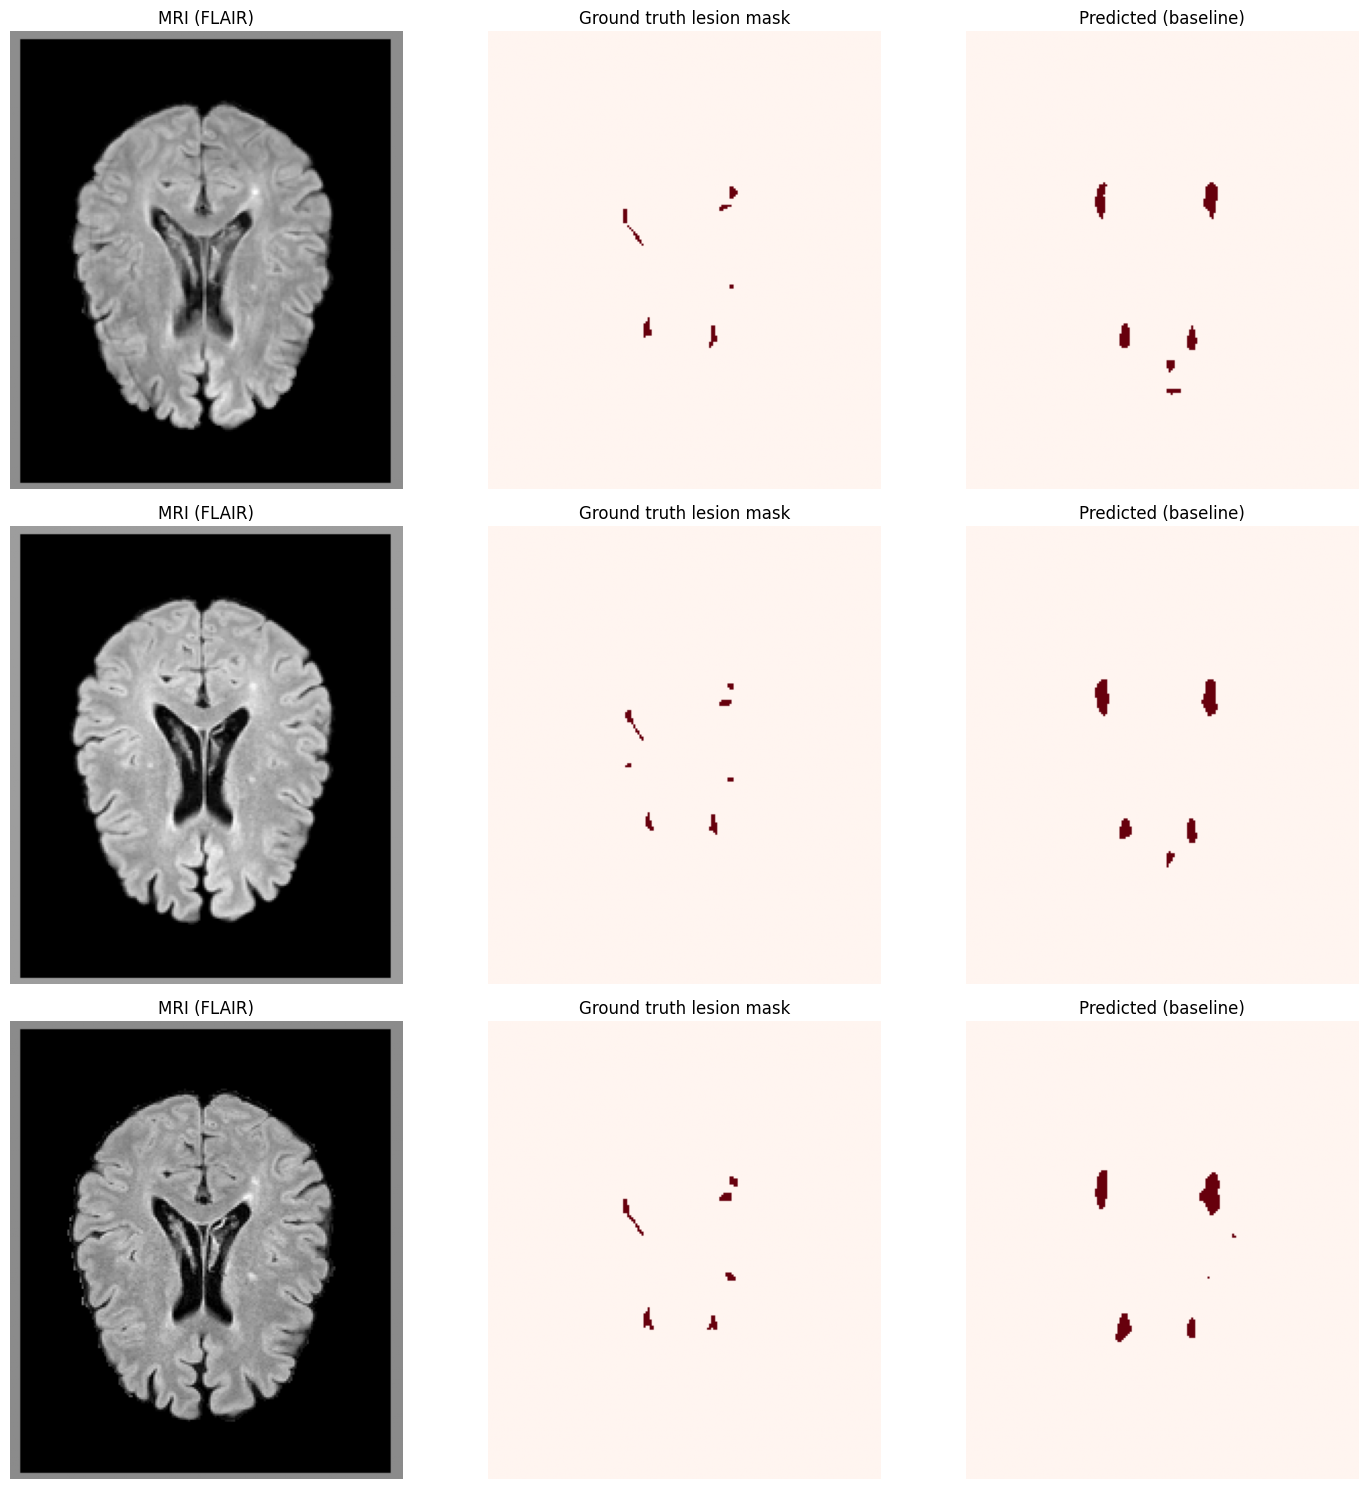

In [13]:
# Images of the original MRI, ground truth mask and predicted lesions using
# fine-tuned BraTS model

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(saved_examples), 3, figsize=(15, 5 * len(saved_examples)))

for row, (flair, gt_tensor, pred_mask) in enumerate(saved_examples):
    slice_idx = pred_mask.shape[-1] // 2

    axes[row, 0].imshow(flair[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[row, 0].set_title('MRI (FLAIR)')

    axes[row, 1].imshow(gt_tensor[0, 0, :, :, slice_idx].cpu().T, cmap='Reds', origin='lower')
    axes[row, 1].set_title('Ground truth lesion mask')

    axes[row, 2].imshow(pred_mask[0, 0, :, :, slice_idx].cpu().T, cmap='Reds', origin='lower')
    axes[row, 2].set_title('Predicted (baseline)')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ISBI 2015 Data/finetuned_images.png")
plt.show()